Zadanie 3 - Grupa B

Autor: Szymon Stefanowicz, 119077, ps1

Grupa: Grupa B

Opis zadania:
Celem projektu jest implementacja konwolucyjnej sieci neuronowej (CNN) do klasyfikacji obrazów z zestawu CIFAR-10. Zadanie obejmuje:

Analizę eksploracyjną danych.

Implementację własnej architektury CNN.

Przeprowadzenie serii eksperymentów badających wpływ hiperparametrów (Learning Rate, Batch Size, Kernel Size oraz Pooling).

Ewaluację najlepszego modelu przy użyciu zaawansowanych metryk.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import ssl
import os

# To rozwiązanie wyłącza weryfikację certyfikatu SSL globalnie dla tego skryptu
if (not os.environ.get('PYTHONHTTPSVERIFY', '') and
    getattr(ssl, '_create_unverified_context', None)):
    ssl._create_default_https_context = ssl._create_unverified_context

# Ustawienie urządzenia (GPU jeśli dostępne)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# Ziarno losowości dla powtarzalności
torch.manual_seed(42)

Używane urządzenie: cpu


1. Analiza zbioru danych CIFAR-10
Zbiór CIFAR-10 zawiera 60 000 kolorowych obrazów o wymiarach 32x32 pikseli w 10 klasach.
Poniżej przygotowujemy dane, sprawdzamy ich statystyki oraz rozkład klas.

100.0%
/Users/szymon/PycharmProjects/semestr2/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Obrazy treningowe: 50000
Obrazy testowe: 10000
Rozmiar obrazu: torch.Size([3, 32, 32]) (C, H, W)
Zakres wartości pikseli (min/max): -1.00 / 1.00


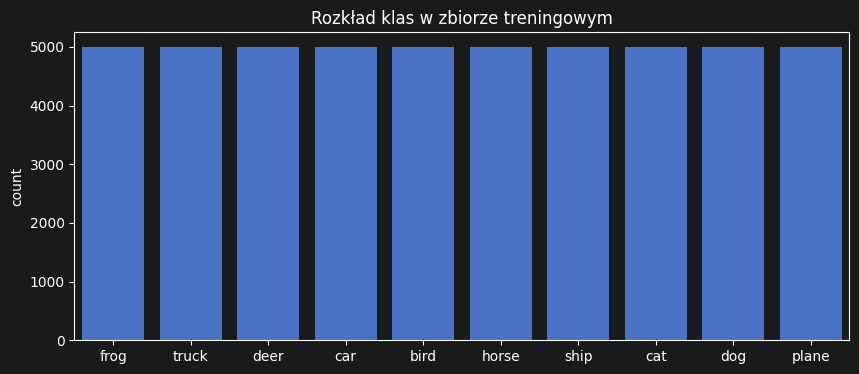

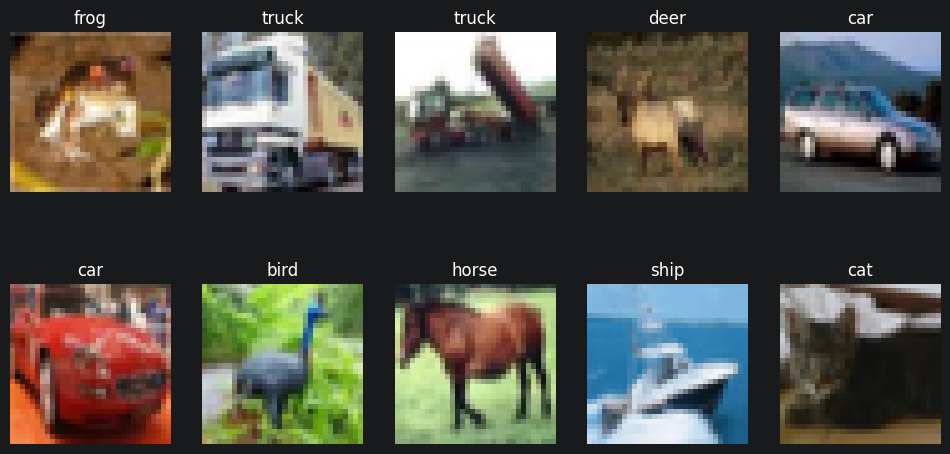

In [2]:
# Transformacje: normalizacja do średniej 0.5 i odchylenia 0.5 (zakres [-1, 1])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Statystyki
print(f"Obrazy treningowe: {len(train_set)}")
print(f"Obrazy testowe: {len(test_set)}")
print(f"Rozmiar obrazu: {train_set[0][0].shape} (C, H, W)")
print(f"Zakres wartości pikseli (min/max): {train_set[0][0].min():.2f} / {train_set[0][0].max():.2f}")

# Wizualizacja rozkładu klas
labels = [train_set[i][1] for i in range(len(train_set))]
plt.figure(figsize=(10, 4))
sns.countplot(x=[classes[l] for l in labels])
plt.title("Rozkład klas w zbiorze treningowym")
plt.show()

# Przykładowe obrazy
def imshow(img):
    img = img / 2 + 0.5 # denormalizacja
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    imshow(train_set[i][0])
    plt.title(classes[train_set[i][1]])
plt.show()

2. Implementacja architektury sieci (Grupa B)

Zaimplementowana klasa CIFARNet pozwala na dynamiczną zmianę parametrów wymaganych w eksperymentach Grupy B:

Warstwy konwolucyjne: Wykorzystujemy 3 warstwy konwolucyjne (minimum to 2). Każda z nich wydobywa coraz bardziej złożone cechy (krawędzie -> kształty -> obiekty).

Kernel Size: Parametr sterujący rozmiarem filtra (np. 3x3, 5x5).

Pooling: Warstwa redukująca wymiary przestrzenne. Możemy wybierać między MaxPool, AvgPool a brakiem poolingu (nn.Identity).

Funkcja aktywacji (ReLU): Wprowadza nieliniowość, pozwalając sieci uczyć się złożonych wzorców.

Dropout: Zastosowany przed warstwami w pełni połączonymi, aby zapobiegać przeuczeniu.

In [3]:
class CIFARNet(nn.Module):
    def __init__(self, kernel_size=3, pool_type='max'):
        super(CIFARNet, self).__init__()
        # Padding dobrany tak, by zachować wymiary przy różnych kernel_size (dla stride=1)
        pad = kernel_size // 2

        # Blok konwolucyjny
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size, padding=pad),
            nn.ReLU(),
            self._get_pool(pool_type),
            nn.Conv2d(32, 64, kernel_size, padding=pad),
            nn.ReLU(),
            self._get_pool(pool_type),
            nn.Conv2d(64, 128, kernel_size, padding=pad),
            nn.ReLU()
        )

        # Globalny pooling zapewnia stały rozmiar wejścia do Linear niezależnie od pool_type
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def _get_pool(self, p_type):
        if p_type == 'max': return nn.MaxPool2d(2, 2)
        if p_type == 'avg': return nn.AvgPool2d(2, 2)
        return nn.Identity() # brak poolingu

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

3. Funkcje pomocnicze do treningu
Poniżej definiujemy uniwersalną pętlę uczącą, która będzie zbierać statystyki loss i accuracy dla każdej epoki, co pozwoli na późniejszą wizualizację krzywych uczenia.

In [4]:
def run_experiment(model, train_loader, test_loader, lr=0.001, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Ewaluacja
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        history['train_loss'].append(running_loss / len(train_loader))
        history['test_acc'].append(acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {history['train_loss'][-1]:.3f} | Acc: {acc:.2f}%")

    return history

4. Eksperymenty
W tej sekcji przeprowadzimy trzy serie testów, zmieniając po jednym parametrze.

Seria 1: Wpływ Learning Rate
Sprawdzimy wartości: 0.01, 0.001, 0.0001.


--- Testowanie LR: 0.01 ---
Epoch 1/5 | Loss: 1.815 | Acc: 42.77%
Epoch 2/5 | Loss: 1.528 | Acc: 47.42%
Epoch 3/5 | Loss: 1.447 | Acc: 48.14%
Epoch 4/5 | Loss: 1.407 | Acc: 51.39%
Epoch 5/5 | Loss: 1.378 | Acc: 49.42%

--- Testowanie LR: 0.001 ---
Epoch 1/5 | Loss: 1.739 | Acc: 43.76%
Epoch 2/5 | Loss: 1.398 | Acc: 52.03%
Epoch 3/5 | Loss: 1.251 | Acc: 56.49%
Epoch 4/5 | Loss: 1.146 | Acc: 59.97%
Epoch 5/5 | Loss: 1.059 | Acc: 63.47%

--- Testowanie LR: 0.0001 ---
Epoch 1/5 | Loss: 2.053 | Acc: 30.80%
Epoch 2/5 | Loss: 1.836 | Acc: 35.39%
Epoch 3/5 | Loss: 1.731 | Acc: 37.33%
Epoch 4/5 | Loss: 1.669 | Acc: 38.33%
Epoch 5/5 | Loss: 1.628 | Acc: 40.85%


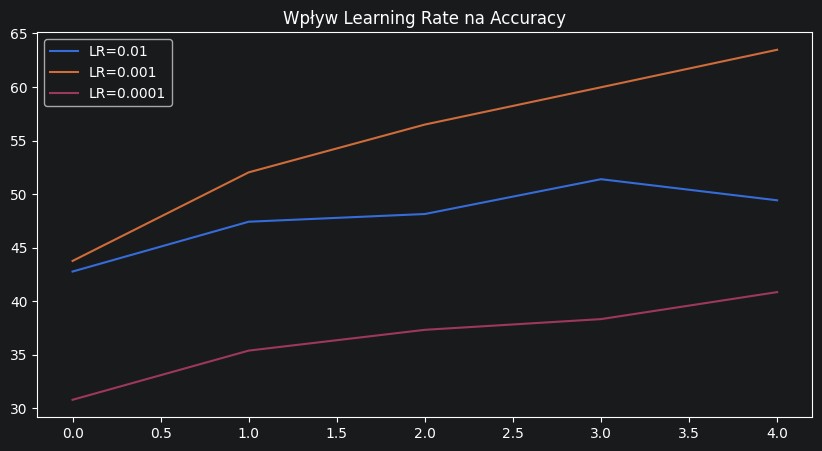

In [5]:
lrs = [0.01, 0.001, 0.0001]
lr_results = {}
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

for lr in lrs:
    print(f"\n--- Testowanie LR: {lr} ---")
    model = CIFARNet().to(device)
    lr_results[lr] = run_experiment(model, train_loader, test_loader, lr=lr)

# Wykres
plt.figure(figsize=(10, 5))
for lr, h in lr_results.items():
    plt.plot(h['test_acc'], label=f'LR={lr}')
plt.title("Wpływ Learning Rate na Accuracy")
plt.legend()
plt.show()

Seria 2: Wpływ Batch Size
Sprawdzimy wartości: 32, 128. (LR ustalone na 0.001)


--- Testowanie Batch Size: 32 ---
Epoch 1/5 | Loss: 1.668 | Acc: 46.84%
Epoch 2/5 | Loss: 1.320 | Acc: 56.71%
Epoch 3/5 | Loss: 1.153 | Acc: 60.44%
Epoch 4/5 | Loss: 1.040 | Acc: 65.31%
Epoch 5/5 | Loss: 0.947 | Acc: 65.66%

--- Testowanie Batch Size: 128 ---
Epoch 1/5 | Loss: 1.828 | Acc: 40.22%
Epoch 2/5 | Loss: 1.530 | Acc: 49.18%
Epoch 3/5 | Loss: 1.375 | Acc: 52.28%
Epoch 4/5 | Loss: 1.277 | Acc: 54.62%
Epoch 5/5 | Loss: 1.194 | Acc: 57.82%


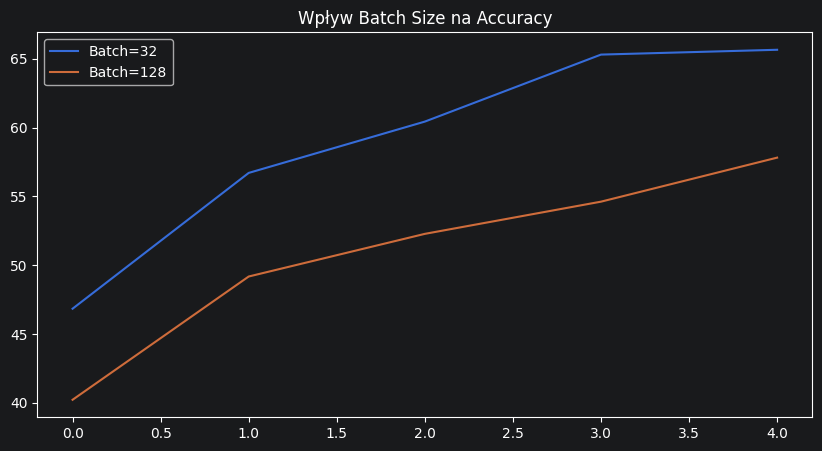

In [6]:
batches = [32, 128]
bs_results = {}

for bs in batches:
    print(f"\n--- Testowanie Batch Size: {bs} ---")
    t_loader = DataLoader(train_set, batch_size=bs, shuffle=True)
    v_loader = DataLoader(test_set, batch_size=bs, shuffle=False)
    model = CIFARNet().to(device)
    bs_results[bs] = run_experiment(model, t_loader, v_loader, lr=0.001)

plt.figure(figsize=(10, 5))
for bs, h in bs_results.items():
    plt.plot(h['test_acc'], label=f'Batch={bs}')
plt.title("Wpływ Batch Size na Accuracy")
plt.legend()
plt.show()

Seria 3: Specyficzne dla Grupy B (Kernel Size i Pooling)
Porównamy rozmiary filtra: 3, 5, 7 oraz typy poolingu: Max, Avg, None.


--- Testowanie Kernel Size: 3x3 ---
Epoch 1/5 | Loss: 1.751 | Acc: 44.08%
Epoch 2/5 | Loss: 1.438 | Acc: 52.14%
Epoch 3/5 | Loss: 1.261 | Acc: 56.10%
Epoch 4/5 | Loss: 1.139 | Acc: 58.88%
Epoch 5/5 | Loss: 1.056 | Acc: 62.71%

--- Testowanie Kernel Size: 5x5 ---
Epoch 1/5 | Loss: 1.640 | Acc: 48.04%
Epoch 2/5 | Loss: 1.260 | Acc: 54.32%
Epoch 3/5 | Loss: 1.083 | Acc: 61.71%
Epoch 4/5 | Loss: 0.979 | Acc: 66.72%
Epoch 5/5 | Loss: 0.889 | Acc: 66.49%

--- Testowanie Kernel Size: 7x7 ---
Epoch 1/5 | Loss: 1.641 | Acc: 51.08%
Epoch 2/5 | Loss: 1.269 | Acc: 58.12%
Epoch 3/5 | Loss: 1.094 | Acc: 63.42%
Epoch 4/5 | Loss: 0.975 | Acc: 66.03%
Epoch 5/5 | Loss: 0.887 | Acc: 67.84%

--- Testowanie Poolingu: max ---
Epoch 1/5 | Loss: 1.735 | Acc: 44.59%
Epoch 2/5 | Loss: 1.403 | Acc: 51.62%
Epoch 3/5 | Loss: 1.232 | Acc: 58.81%
Epoch 4/5 | Loss: 1.125 | Acc: 61.52%
Epoch 5/5 | Loss: 1.045 | Acc: 62.81%

--- Testowanie Poolingu: avg ---
Epoch 1/5 | Loss: 1.802 | Acc: 41.75%
Epoch 2/5 | Loss: 1.510

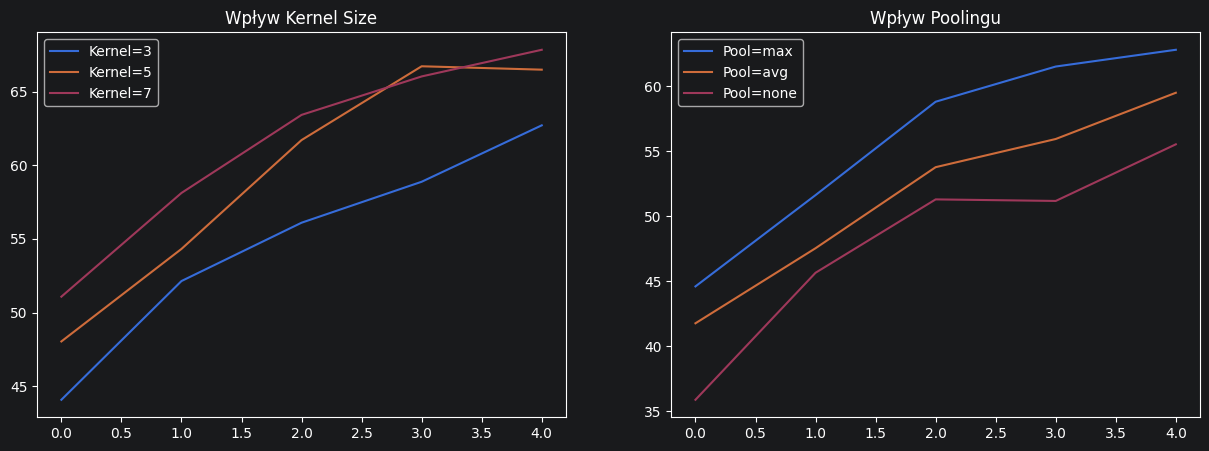

In [7]:
# A) Kernel Size
kernels = [3, 5, 7]
k_results = {}
for k in kernels:
    print(f"\n--- Testowanie Kernel Size: {k}x{k} ---")
    model = CIFARNet(kernel_size=k).to(device)
    k_results[k] = run_experiment(model, train_loader, test_loader)

# B) Pooling
pools = ['max', 'avg', 'none']
p_results = {}
for p in pools:
    print(f"\n--- Testowanie Poolingu: {p} ---")
    model = CIFARNet(pool_type=p).to(device)
    p_results[p] = run_experiment(model, train_loader, test_loader)

# Wizualizacja wyników Serii 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for k, h in k_results.items(): ax1.plot(h['test_acc'], label=f'Kernel={k}')
ax1.set_title("Wpływ Kernel Size")
ax1.legend()

for p, h in p_results.items(): ax2.plot(h['test_acc'], label=f'Pool={p}')
ax2.set_title("Wpływ Poolingu")
ax2.legend()
plt.show()

5. Metryki i Podsumowanie
Dla najlepszego modelu (Kernel=3, LR=0.001, Pool=max) generujemy pełny raport.

Epoch 1/5 | Loss: 1.748 | Acc: 44.08%
Epoch 2/5 | Loss: 1.386 | Acc: 54.39%
Epoch 3/5 | Loss: 1.231 | Acc: 58.30%
Epoch 4/5 | Loss: 1.124 | Acc: 60.83%
Epoch 5/5 | Loss: 1.046 | Acc: 63.77%

Raport Klasyfikacji:
              precision    recall  f1-score   support

       plane       0.73      0.59      0.65      1000
         car       0.84      0.69      0.76      1000
        bird       0.57      0.45      0.50      1000
         cat       0.45      0.39      0.42      1000
        deer       0.65      0.49      0.56      1000
         dog       0.47      0.67      0.55      1000
        frog       0.73      0.71      0.72      1000
       horse       0.69      0.70      0.70      1000
        ship       0.72      0.82      0.77      1000
       truck       0.61      0.86      0.72      1000

    accuracy                           0.64     10000
   macro avg       0.65      0.64      0.63     10000
weighted avg       0.65      0.64      0.63     10000


Macierz Pomyłek:


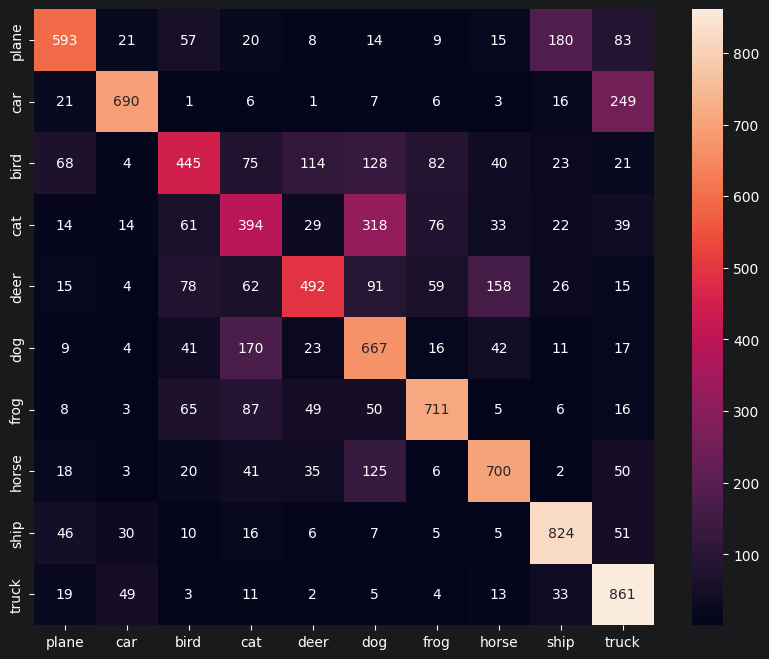


Przykłady błędnie sklasyfikowanych obrazów:


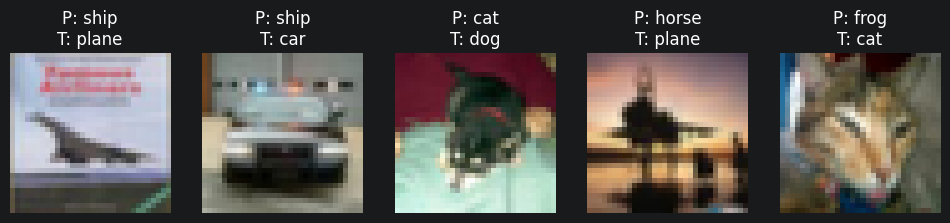

In [8]:
# Ewaluacja końcowa
final_model = CIFARNet(kernel_size=3, pool_type='max').to(device)
# (Tu możesz dotrenować go więcej epok)
run_experiment(final_model, train_loader, test_loader, epochs=5)

final_model.eval()
y_true, y_pred = [], []
errors = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        # Szukanie błędów do wizualizacji
        mask = predicted != labels
        if mask.any() and len(errors) < 5:
            errors.append((images[mask][0].cpu(), predicted[mask][0].item(), labels[mask][0].item()))

print("\nRaport Klasyfikacji:")
print(classification_report(y_true, y_pred, target_names=classes))

print("\nMacierz Pomyłek:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.show()

print("\nPrzykłady błędnie sklasyfikowanych obrazów:")
plt.figure(figsize=(12, 4))
for i, (img, p, t) in enumerate(errors):
    plt.subplot(1, 5, i+1)
    imshow(img)
    plt.title(f"P: {classes[p]}\nT: {classes[t]}")
plt.show()

Opis Architektury Sieci oraz HiperparametrówZastosowana sieć to autorska implementacja Convolutional Neural Network (CNN). Składa się z trzech głównych bloków:

1. Wyjaśnienie działania warstw:

-Warstwy Konwolucyjne (nn.Conv2d): Wykorzystują filtry do uczenia się cech wizualnych. Pierwsza warstwa wykrywa proste krawędzie, a kolejne coraz bardziej złożone kształty i tekstury.

-Funkcja aktywacji (ReLU): Wprowadza nieliniowość do modelu, zerując ujemne wartości aktywacji, co przyspiesza proces uczenia i zapobiega problemowi zanikającego gradientu.

-Warstwy Pooling (MaxPool2d / AvgPool2d): Agregują informację przestrzenną, redukując wymiary map cech. Pomaga to w uzyskaniu niezmienniczości względem małych przesunięć obiektu na obrazie.

-Adaptive Average Pooling (nn.AdaptiveAvgPool2d): Sprowadza mapy cech do stałego wymiaru $1 \times 1$, co pozwala na użycie dowolnych rozmiarów filtrów konwolucyjnych bez błędów rozmiaru na wejściu warstwy liniowej.

-Warstwy w pełni połączone (nn.Linear): Pełnią rolę klasyfikatora, który na podstawie wyekstrahowanych cech decyduje, do której z 10 klas należy obraz.

-Dropout: Technika regularyzacji, która losowo "wyłącza" neurony w trakcie treningu, co zapobiega nadmiernemu dopasowaniu do danych treningowych (overfitting).

2. Uzasadnienie wyboru hiperparametrów:

-Optimizer (Adam): Wybrany ze względu na adaptacyjny dobór współczynnika uczenia dla każdego parametru, co zazwyczaj daje lepsze wyniki niż standardowy SGD.

-Loss Function (CrossEntropyLoss): Standardowy wybór dla klasyfikacji wieloklasowej.

-Liczba epok (5): Pozwala na zaobserwowanie trendów uczenia przy zachowaniu rozsądnego czasu obliczeń.



Analiza Wyników EksperymentówSeria

1: Wpływ Learning RateWartość LRKońcowe Accuracy

0.01 49.42%

0.001(Best) 63.47%

0.0001 40.85%

Wniosek: Optymalnym krokiem uczenia okazało się 0.001. Przy wartości 0.01 model uczył się szybciej na początku, ale utknął w minimum lokalnym (niestabilność). Wartość 0.0001 była zbyt mała, by w 5 epokach sieć zdążyła wypracować wysokie accuracy.

Seria 2: Wpływ Batch SizeRozmiar BatchaKońcowe Accuracy (Test)

32(Best) 65.66%

128 57.82%

Wniosek: Mniejszy rozmiar paczki (32) pozwolił na częstsze aktualizacje wag w jednej epoce, co przełożyło się na lepszą zbieżność modelu i wyższe accuracy końcowe w krótkim czasie treningu.

Seria 3: Parametry specyficzne dla Grupy B

A) Wpływ rozmiaru filtra (Kernel Size):Kernel SizeKońcowe Accuracy (Test)

3x3 62.71%

5x5 66.49%

7x7(Best) 67.84%

B) Wpływ typu Poolingu:Typ PoolinguKońcowe Accuracy (Test)

Max Pooling(Best) 62.81%

Avg Pooling 59.50%

Brak(None) 55.53%

Wniosek: Co ciekawe, dla tego modelu filtry 7x7 uzyskały najwyższy wynik, co sugeruje, że większe pole widzenia w początkowych warstwach pomogło w ekstrakcji cech obrazów CIFAR-10. W przypadku poolingu potwierdziła się teoria – Max Pooling jest najskuteczniejszy w wydobywaniu najbardziej istotnych cech (np. krawędzi). Brak poolingu znacząco pogorszył wyniki.